Ad =
 [[ 0.99984535  0.09953212  0.00452419]
 [-0.00452419  0.98627279  0.08595955]
 [-0.08595955 -0.26240285  0.72839412]]
Cd =
 [[1. 0. 0.]]

Observer gain L =
 [[ 2.11451225]
 [12.15090928]
 [15.49144942]]
Observer poles eig(Ad - L Cd) = [0.1 0.2 0.3]


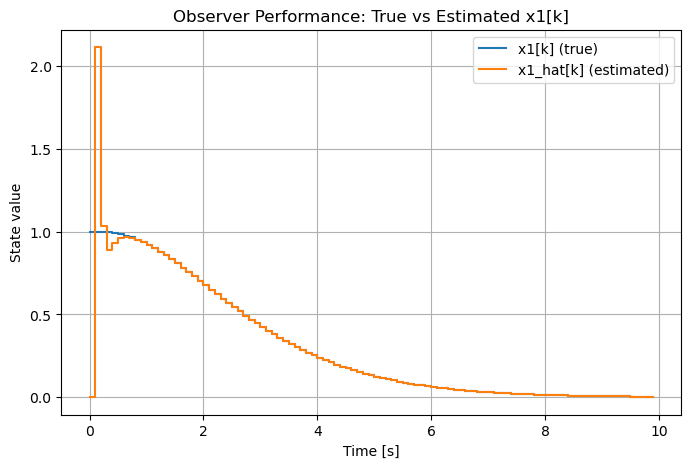

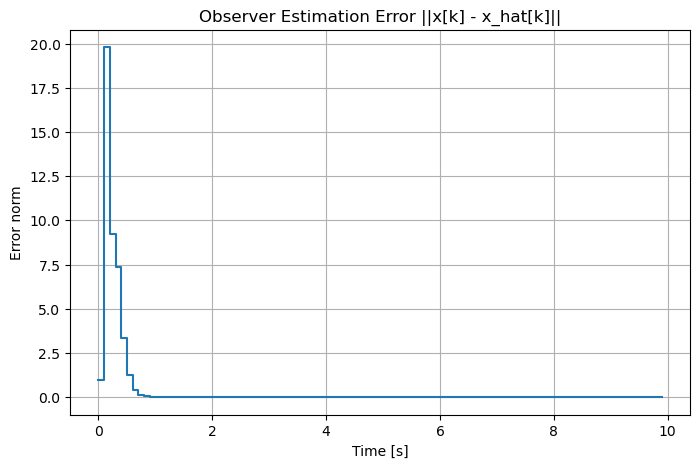

In [9]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

# -----------------------------------------
# 1) Discrete-time system
# -----------------------------------------
A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]], dtype=float)

B = np.array([[0],
              [0],
              [1]], dtype=float)

C = np.array([[1, 0, 0]], dtype=float)
D = np.array([[0]], dtype=float)

Ts = 0.1
sys_c = ctrl.ss(A, B, C, D)
sys_d = ctrl.c2d(sys_c, Ts)

Ad = np.array(sys_d.A, dtype=float)
Bd = np.array(sys_d.B, dtype=float)
Cd = np.array(sys_d.C, dtype=float)
Dd = np.array(sys_d.D, dtype=float)

print("Ad =\n", Ad)
print("Cd =\n", Cd)

# -----------------------------------------
# 2) Observer gain L via pole placement
#    Place eigenvalues of (Ad - L Cd)
# -----------------------------------------
p_obs = [0.1, 0.2, 0.3]
L = ctrl.acker(Ad.T, Cd.T, p_obs).T  # shape (3,1) usually
L = np.array(L, dtype=float).reshape(3, 1)

print("\nObserver gain L =\n", L)

# (Optional) check observer poles
eig_obs = np.linalg.eigvals(Ad - L @ Cd)
print("Observer poles eig(Ad - L Cd) =", np.round(eig_obs, 6))

# -----------------------------------------
# 3) Simulate true system and observer
# -----------------------------------------
steps = 100
x = np.zeros((3, steps), dtype=float)
x_hat = np.zeros((3, steps), dtype=float)

x[:, 0] = np.array([1.0, 0.0, 0.0])      # true initial state
x_hat[:, 0] = np.array([0.0, 0.0, 0.0])  # initial estimate

for k in range(steps - 1):
    # true system (no input)
    x[:, k+1] = Ad @ x[:, k]

    # measurement y_k (make it a scalar)
    y_k = (Cd @ x[:, k]).item()

    # estimated measurement yhat_k (scalar)
    yhat_k = (Cd @ x_hat[:, k]).item()

    # innovation / estimation error (scalar)
    e_k = y_k - yhat_k

    # observer update: x_hat[k+1] = Ad x_hat[k] + L e_k
    x_hat[:, k+1] = Ad @ x_hat[:, k] + (L[:, 0] * e_k)

# time axis
t_disc = np.arange(steps) * Ts

# -----------------------------------------
# 4) Plots
# -----------------------------------------
plt.figure(figsize=(8, 5))
plt.step(t_disc, x[0, :], where='post', label='x1[k] (true)')
plt.step(t_disc, x_hat[0, :], where='post', label='x1_hat[k] (estimated)')
plt.title("Observer Performance: True vs Estimated x1[k]")
plt.xlabel("Time [s]")
plt.ylabel("State value")
plt.grid(True)
plt.legend()
plt.show()

# Estimation error norm
err = np.linalg.norm(x - x_hat, axis=0)

plt.figure(figsize=(8, 5))
plt.step(t_disc, err, where='post')
plt.title("Observer Estimation Error ||x[k] - x_hat[k]||")
plt.xlabel("Time [s]")
plt.ylabel("Error norm")
plt.grid(True)
plt.show()


Continuous-time model created.

State feedback gain K: [[23. 23.  6.]]
Closed-loop eigenvalues (A - B K): [-2. -3. -4.]
Feedforward gain W: 24.0


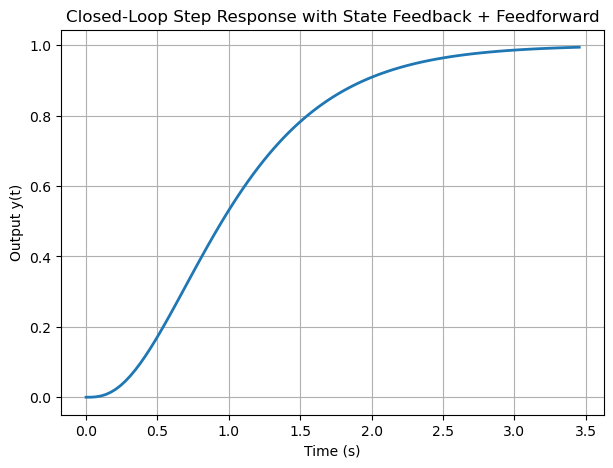

In [7]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]])

B = np.array([[0],
              [0],
              [1]])

C = np.array([[1, 0, 0]])
D = np.array([[0]])

sys_c = ctrl.ss(A, B, C, D)
print("Continuous-time model created.\n")

desired_poles = [-2, -3, -4]
K = ctrl.acker(A, B, desired_poles).reshape(1, 3)
print("State feedback gain K:", K)

Ak = A - B @ K
eig_cl = np.linalg.eigvals(Ak)
print("Closed-loop eigenvalues (A - B K):", eig_cl)

# --- FIX HERE ---
scalar = (C @ np.linalg.solve(Ak, B)).item()
W = -1.0 / scalar
print("Feedforward gain W:", W)

B_cl = B * W
sys_cl = ctrl.ss(Ak, B_cl, C, D)

t_cl, y_cl = ctrl.step_response(sys_cl)

plt.figure(figsize=(7,5))
plt.plot(t_cl, y_cl, linewidth=2)
plt.title("Closed-Loop Step Response with State Feedback + Feedforward")
plt.xlabel("Time (s)")
plt.ylabel("Output y(t)")
plt.grid(True)
plt.show()


Continuous-time model created.

Discrete-time matrices:
Ad =
 [[ 0.99984535  0.09953212  0.00452419]
 [-0.00452419  0.98627279  0.08595955]
 [-0.08595955 -0.26240285  0.72839412]]
Bd =
 [[0.00015465]
 [0.00452419]
 [0.08595955]]
Cd =
 [[1. 0. 0.]]
Dd =
 [[0.]]

Eigenvalues of Ad: [0.90483921+0.00000000e+00j 0.90483652+1.55292972e-06j
 0.90483652-1.55292972e-06j]
Rounded eigenvalues of Ad: [0.9048+0.j 0.9048+0.j 0.9048-0.j]


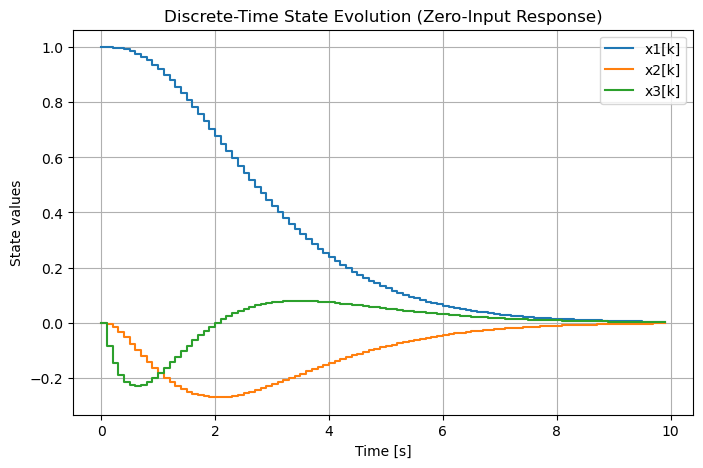

In [5]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

# -----------------------------------------
# 1) Continuous-time state-space model
# -----------------------------------------

A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]])

B = np.array([[0],
              [0],
              [1]])

C = np.array([[1, 0, 0]])
D = np.array([[0]])

sys_c = ctrl.ss(A, B, C, D)
print("Continuous-time model created.\n")

# -----------------------------------------
# 2) Discretise the system (c2d with ZOH)
# -----------------------------------------

Ts = 0.1  # sampling time [s], same as in lab
sys_d = ctrl.c2d(sys_c, Ts)

Ad = sys_d.A
Bd = sys_d.B
Cd = sys_d.C
Dd = sys_d.D

print("Discrete-time matrices:")
print("Ad =\n", Ad)
print("Bd =\n", Bd)
print("Cd =\n", Cd)
print("Dd =\n", Dd)

# -----------------------------------------
# 3) Eigenvalues of Ad (discrete stability)
# -----------------------------------------

eigs_Ad = np.linalg.eigvals(Ad)
print("\nEigenvalues of Ad:", eigs_Ad)
print("Rounded eigenvalues of Ad:", np.round(eigs_Ad, 4))

# -----------------------------------------
# 4) Zero-input discrete simulation
#     x[k+1] = Ad x[k] + Bd u[k], with u[k] = 0
# -----------------------------------------

steps = 100
x0 = np.array([1.0, 0.0, 0.0])   # initial state [1; 0; 0]
X = np.zeros((3, steps))
X[:, 0] = x0

u = 0.0  # zero input

for k in range(steps - 1):
    X[:, k+1] = Ad @ X[:, k] + Bd.flatten() * u

# time vector for plotting
t_disc = np.arange(steps) * Ts

# -----------------------------------------
# 5) Plot discrete state trajectories
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.step(t_disc, X[0, :], where='post', label='x1[k]')
plt.step(t_disc, X[1, :], where='post', label='x2[k]')
plt.step(t_disc, X[2, :], where='post', label='x3[k]')
plt.title("Discrete-Time State Evolution (Zero-Input Response)")
plt.xlabel("Time [s]")
plt.ylabel("State values")
plt.grid(True)
plt.legend()
plt.show()


Eigenvalues of A: [-1.00001 +0.e+00j -0.999995+8.e-06j -0.999995-8.e-06j]
Rank of controllability matrix: 3
Rank of observability matrix: 3


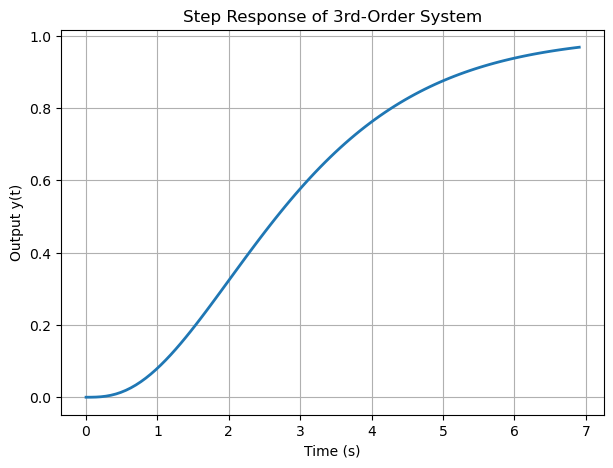

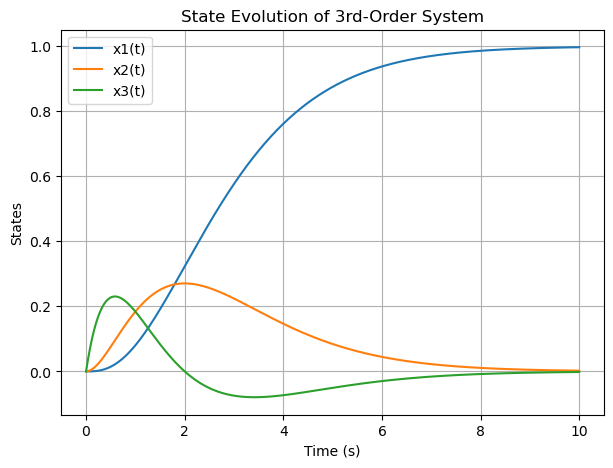

In [4]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

# -----------------------------------------
# STEP 1 — Create the State-Space Model
# -----------------------------------------
A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]])

B = np.array([[0],
              [0],
              [1]])

C = np.array([[1, 0, 0]])
D = np.array([[0]])

sys = ctrl.ss(A, B, C, D)

# -----------------------------------------
# STEP 2 — Eigenvalues, Controllability, Observability
# -----------------------------------------
eigvals = np.linalg.eigvals(A)
print("Eigenvalues of A:", np.round(eigvals, 6))

Co = ctrl.ctrb(A, B)
print("Rank of controllability matrix:", np.linalg.matrix_rank(Co))

Ob = ctrl.obsv(A, C)
print("Rank of observability matrix:", np.linalg.matrix_rank(Ob))

# -----------------------------------------
# STEP 3 — Step Response
# -----------------------------------------
t, y = ctrl.step_response(sys)

plt.figure(figsize=(7,5))
plt.plot(t, y, linewidth=2)
plt.title("Step Response of 3rd-Order System")
plt.xlabel("Time (s)")
plt.ylabel("Output y(t)")
plt.grid(True)
plt.show()

# -----------------------------------------
# STEP 4 — State Evolution
# -----------------------------------------
T = np.linspace(0, 10, 500)
u = np.ones_like(T)

t_out, y_out, x_out = ctrl.forced_response(sys, T, u, return_x=True)

plt.figure(figsize=(7,5))
plt.plot(t_out, x_out[0], label="x1(t)")
plt.plot(t_out, x_out[1], label="x2(t)")
plt.plot(t_out, x_out[2], label="x3(t)")
plt.title("State Evolution of 3rd-Order System")
plt.xlabel("Time (s)")
plt.ylabel("States")
plt.grid(True)
plt.legend()
plt.show()


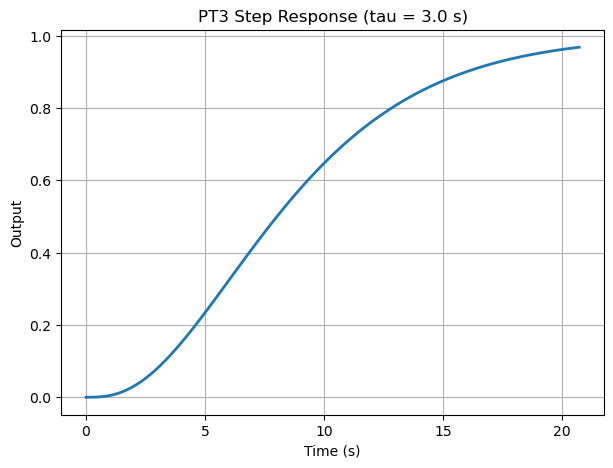

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# PT3 System
tau3 = 3.0
G3 = ctrl.tf([1], [tau3, 1])**3

# Step response
t3, y3 = ctrl.step_response(G3)

# Plot
plt.figure(figsize=(7,5))
plt.plot(t3, y3, linewidth=2)
plt.title("PT3 Step Response (tau = 3.0 s)")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)
plt.show()


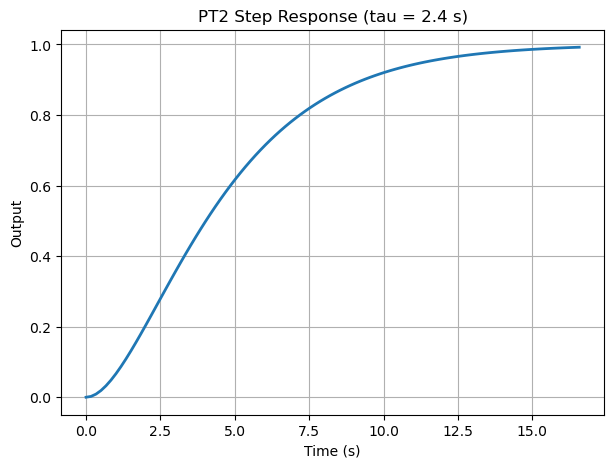

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# PT2 System
tau2 = 2.4
G2 = ctrl.tf([1], [tau2, 1])**2

# Step response
t2, y2 = ctrl.step_response(G2)

# Plot
plt.figure(figsize=(7,5))
plt.plot(t2, y2, linewidth=2)
plt.title("PT2 Step Response (tau = 2.4 s)")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)
plt.show()


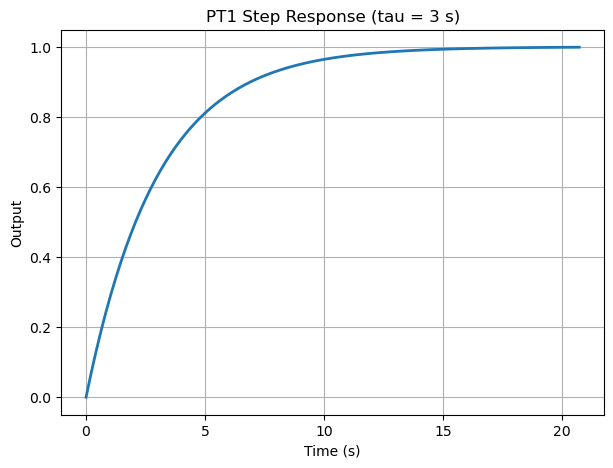

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# PT1 System
tau1 = 3.0
G1 = ctrl.tf([1], [tau1, 1])

# Step response
t1, y1 = ctrl.step_response(G1)

# Plot
plt.figure(figsize=(7,5))
plt.plot(t1, y1, linewidth=2)
plt.title("PT1 Step Response (tau = 3 s)")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)
plt.show()
